# Chapter 3 (Hull) — Hedging Strategies Using Futures 

This chapter is about **hedging** with futures.

- A **perfect hedge** would eliminate all risk, but in practice hedges are usually **imperfect**.
- The goal is often to **reduce risk as much as possible**, using a futures position that offsets the exposure in the underlying.

We keep the same structure as before:
1. Basic principles (short hedge vs long hedge)
2. Simple examples (oil producer, copper user)
3. Arguments for and against hedging
4. Basis risk (definition of the basis + why hedges are imperfect)
5. Choice of contract (which futures to use + which delivery month)

## 3.1 Basic Principles

When a company hedges with futures, it typically takes a futures position that offsets price risk:

- If you will **SELL** the asset in the future → you fear the price might **fall** → you use a **short hedge** (sell futures).
- If you will **BUY** the asset in the future → you fear the price might **rise** → you use a **long hedge** (buy futures).

Key intuition:
- **Short hedge** protects against a price decrease.
- **Long hedge** protects against a price increase.

### Short Hedge (Sell Futures)

A short hedge is appropriate when:
- you already own the asset, or
- you will produce it and sell it later, and you want to lock in a selling price.

Mechanism:
- If spot price decreases → your physical sale is worse, but your short futures gains.
- If spot price increases → your physical sale is better, but your short futures loses.

Goal: stabilize the final effective selling price.

In [1]:
import numpy as np

# Hull-like numbers (didactic)
barrels = 1_000_000
F0 = 49.0          # futures price when hedge is initiated
ST_scenarios = [45.0, 55.0]  # possible spot prices at the sale date (near delivery)

def short_hedge_effective_price(F0, ST):
    """
    Short hedge:
    - Sell the physical at ST
    - Futures gain approx (F0 - ST) when closing out near delivery
    Effective price approx = ST + (F0 - ST) = F0
    """
    return ST + (F0 - ST)

print("=== Short hedge: effective selling price ===")
for ST in ST_scenarios:
    effective = short_hedge_effective_price(F0, ST)
    revenue = barrels * effective
    print(f"S_T={ST:.2f} -> effective price ≈ {effective:.2f} -> total revenue ≈ ${revenue:,.0f}")

=== Short hedge: effective selling price ===
S_T=45.00 -> effective price ≈ 49.00 -> total revenue ≈ $49,000,000
S_T=55.00 -> effective price ≈ 49.00 -> total revenue ≈ $49,000,000


**Interpretation (Hull-level):**
- In a clean textbook setting (futures price close to spot at delivery), the effective selling price is close to the initial futures price \(F_0\).
- In reality, it will not be exactly \(F_0\) because of **basis risk** (later in the chapter).

### Long Hedge (Buy Futures)

A long hedge is appropriate when:
- you will need to **buy** an asset in the future
- and you want to lock in an approximate purchase price today.

Mechanism:
- If spot price increases → your physical purchase is more expensive, but your long futures gains.
- If spot price decreases → your physical purchase is cheaper, but your long futures loses.

Goal: stabilize the final effective purchase price.

In [2]:
# Hull-like numbers (didactic)
pounds = 100_000
F0 = 3.20           # futures price in $/lb when hedge is initiated (e.g., 320 cents)
ST_scenarios = [3.25, 3.05]

def long_hedge_effective_price(F0, ST):
    """
    Long hedge:
    - Buy the physical at ST
    - Futures gain approx (ST - F0)
    Effective cost ≈ ST - (ST - F0) = F0
    """
    return ST - (ST - F0)

print("=== Long hedge: effective purchase price ===")
for ST in ST_scenarios:
    effective = long_hedge_effective_price(F0, ST)
    cost = pounds * effective
    print(f"S_T={ST:.2f} -> effective price ≈ {effective:.2f} -> total cost ≈ ${cost:,.0f}")

=== Long hedge: effective purchase price ===
S_T=3.25 -> effective price ≈ 3.20 -> total cost ≈ $320,000
S_T=3.05 -> effective price ≈ 3.20 -> total cost ≈ $320,000


## 3.2 Arguments for and Against Hedging

Hull explains that hedging is common, but not universal.

### Arguments for hedging
- Firms often have no special skill at predicting prices (commodities, FX, rates).
- Hedging reduces unpleasant surprises and stabilizes cash flows/margins.
- It allows managers to focus on their core business.

### Arguments against hedging (Hull-style discussion points)
- Shareholders can diversify risk themselves; the firm might not need to hedge on their behalf.
- If competitors do not hedge, hedging can affect relative performance (your margins may behave differently).
- Hedging can sometimes lead to a **worse outcome** than no hedge (you may regret giving up upside).

Key point:
Hedging is **risk management**, not profit maximization.

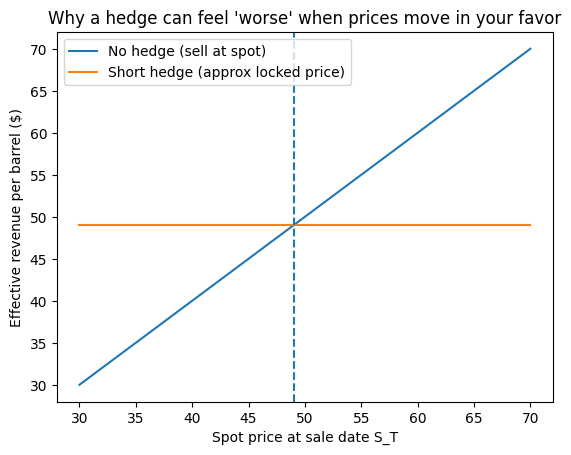

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Simple short hedge example: producer locks F0, but spot rises.
F0 = 49
ST = np.linspace(30, 70, 200)

# No hedge revenue per barrel = ST
rev_no_hedge = ST

# Short hedge effective price approx = F0 (flat)
rev_hedge = np.full_like(ST, F0)

plt.figure()
plt.plot(ST, rev_no_hedge, label="No hedge (sell at spot)")
plt.plot(ST, rev_hedge, label="Short hedge (approx locked price)")
plt.axvline(F0, linestyle="--")
plt.xlabel("Spot price at sale date S_T")
plt.ylabel("Effective revenue per barrel ($)")
plt.title("Why a hedge can feel 'worse' when prices move in your favor")
plt.legend()
plt.show()